In [14]:
import time
import torch
from matplotlib import pyplot as plt
import utils
import random
import numpy as np
import data_bonelesions as kahler
from torch.utils.data import DataLoader
import models
from skimage import measure


test_img_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/images/test/"
test_mask_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/labels/test/"
test_set = kahler.KahlerDataset(test_img_dir, test_mask_dir)

#data loaders
batch_size = 1

test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

device = torch.device("cuda")
model = models.SwinUnetFinetune448()
model.to(device)
model.load_state_dict(torch.load("/wecare/home/daniel/Thesis/models/finetune_lesions_simmim_448_best.pth", weights_only=True), strict=False)
#segment_output_save_path = "/wecare/home/daniel/Thesis/images/segmentations_lesions_simmim.png"
plot_title = "SimMIM pretraining bone lesion segmentation"


SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.1;num_classes:1
---final upsample expand_first---


Number of lesions in q1:152, q2:155, q3:152, q4:155
q1 mean dice: 0.03528549918564921 q1 detection rate: 0.11842105263157898
q2 mean dice: 0.03905279876997699 q2 detection rate: 0.16129032258064513
q3 mean dice: 0.14012990104884007 q3 detection rate: 0.3421052631578947
q4 mean dice: 0.2744450449684168 q4 detection rate: 0.6129032258064516


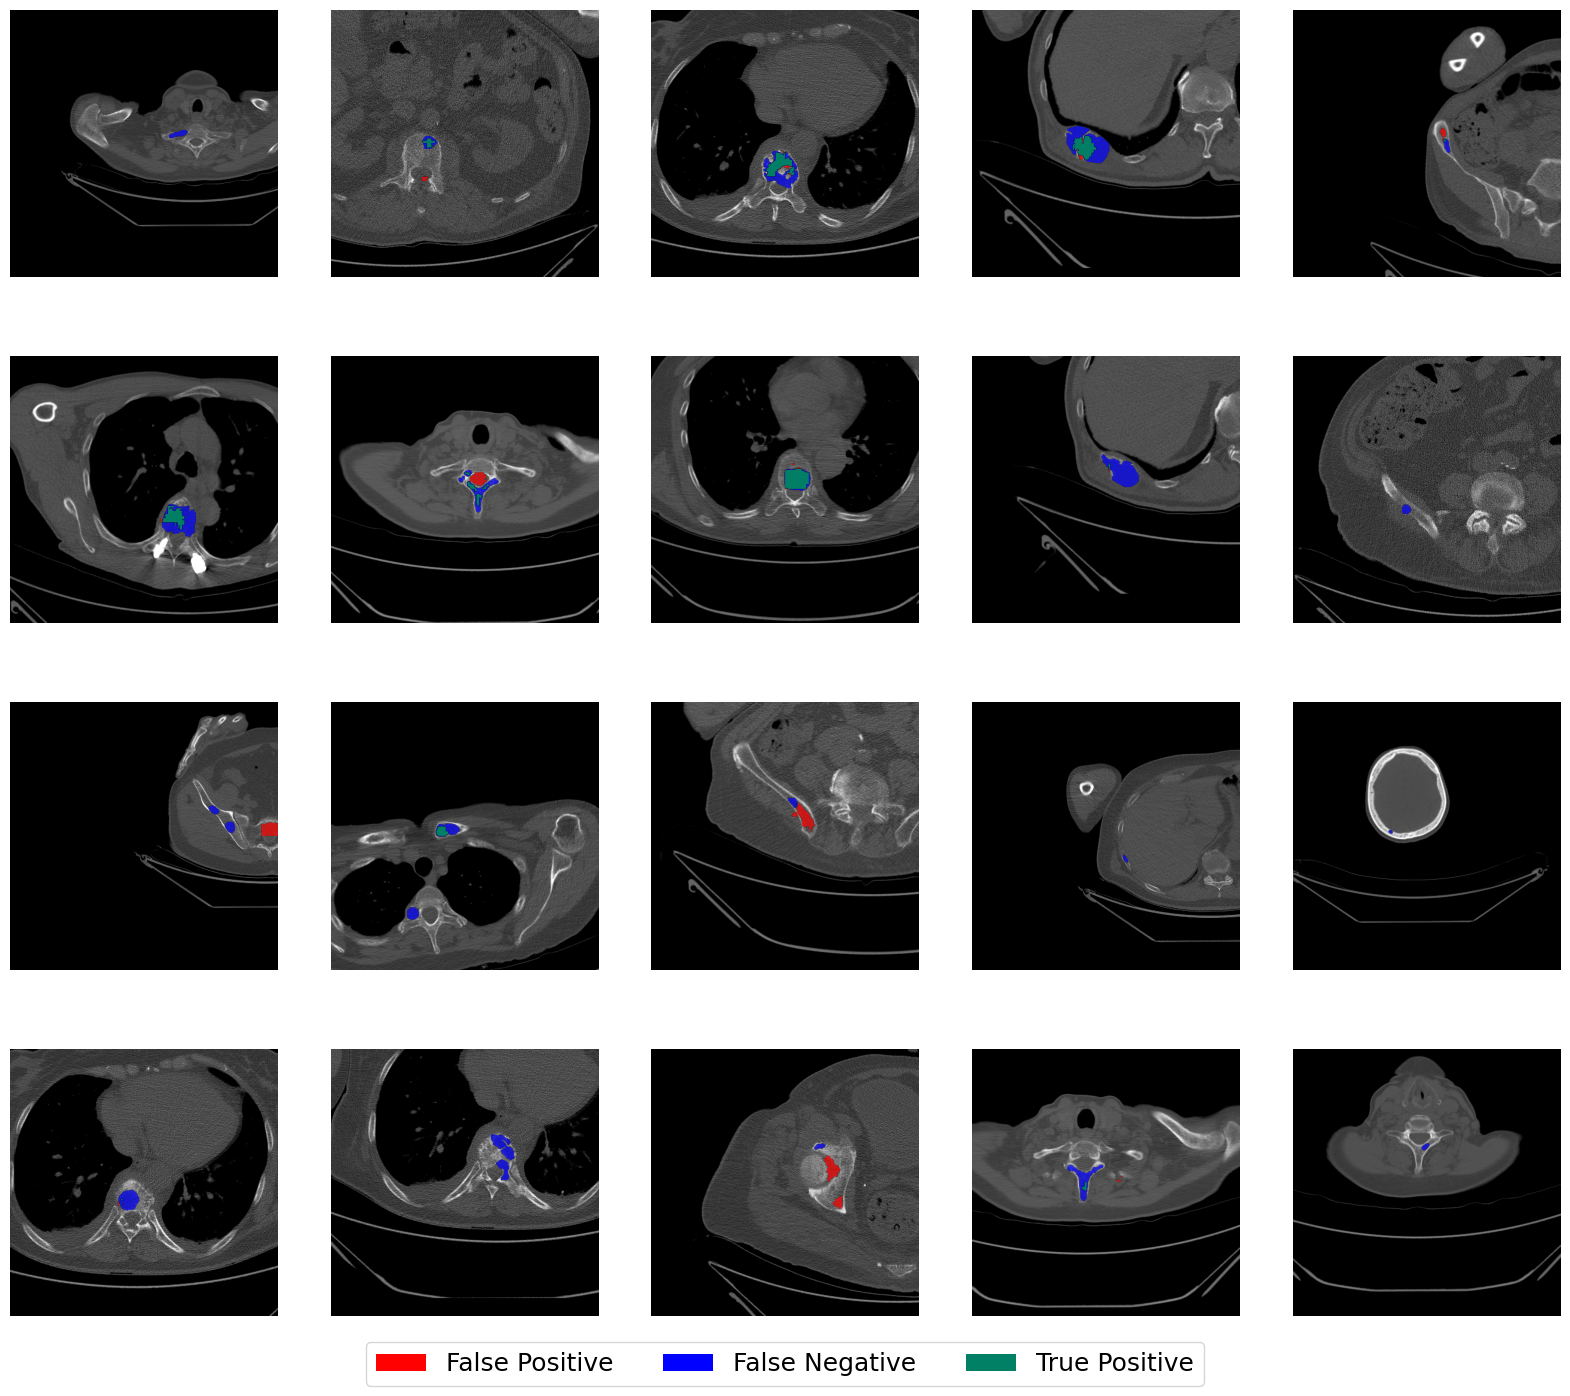

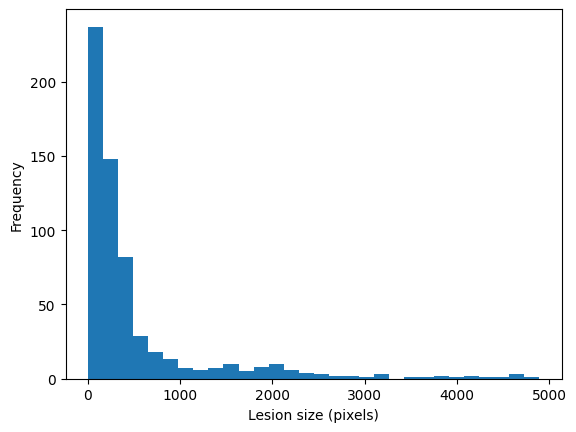

Metrics runtime 81.49768257141113
Mean dice coefficient on test set: 0.1495
Standard deviation of dice coefficient on test set: 0.2447

Mean jaccard coefficient on test set: 0.1055
Mean precision on test set: 0.2712
Mean recall on test set: 0.1399

Number of undetected lesions on test set: 266
Mean dice coefficient for detected lesions: 0.4305
Standard deviation of dice coefficient for detected lesions: 0.2324


<Figure size 640x480 with 0 Axes>

In [15]:

start = time.time()

#dice standard deviation
dice_list = []
iou_list = []
detected_dice_list = []
precision_list = []
recall_list = []
dice_m = 0.0
dice_sd = 0.0
detected_dice_m = 0.0
detected_dice_sd = 0.0
undetected_count = 0

idx_undetected = []
idx_detected = []
idx_random_list = []

size_list = []
lesion_dice_list = []
total_lesions_repeated = 0

model.eval()

with torch.no_grad():
    #unbatching all the test images and masks to calculate metrics individually
    for idx_batch, (images, masks) in enumerate(test_loader):

        images, masks = images.to(device), masks.to(device)

        images_list = torch.unbind(images, dim=0)
        masks_list = torch.unbind(masks, dim=0)

        for idx_inside, (unbatched_image, unbatched_masks) in enumerate(zip(images, masks)):

            unbatched_output = model(unbatched_image.unsqueeze(0))

            #calculating region metrics
            labels = measure.label(unbatched_masks.cpu().numpy(), connectivity=1)
            props = measure.regionprops(labels)
            for prop in props:
                total_lesions_repeated += 1
                #print(prop.bbox)
                _, y_min, x_min, _, y_max, x_max = prop.bbox
                #print(unbatched_output.shape, unbatched_masks.shape)
                lesion_img = unbatched_output.squeeze(0)[:, y_min:y_max, x_min:x_max]
                lesion_label = unbatched_masks[:, y_min:y_max, x_min:x_max]
                lesion_dice, _ = utils.dice_coeff(unbatched_output, unbatched_masks.unsqueeze(0))
                lesion_dice_list.append(lesion_dice)
                size_list.append(torch.sum(lesion_label).item())

            #calculating dice scores
            #print(unbatched_image.shape, unbatched_masks.shape, idx_batch)
            unbatched_dice, _ = utils.dice_coeff(unbatched_output, unbatched_masks.unsqueeze(0))
            dice_list.append(unbatched_dice)

            #calculating iou scores
            unbatched_iou, _ = utils.jaccard_coeff(unbatched_output, unbatched_masks.unsqueeze(0))
            iou_list.append(unbatched_iou)

            #calculating detected lesion dice scores
            if unbatched_dice < 0.05:
                undetected_count += 1
                idx_undetected.append([idx_batch, idx_inside])
            if unbatched_dice >= 0.05:
                detected_dice_list.append(unbatched_dice)
                idx_detected.append([idx_batch, idx_inside])
            idx_random_list.append([idx_batch, idx_inside])

            #calculating precision and recall
            unbatched_precision = utils.precision(unbatched_output, unbatched_masks.unsqueeze(0))
            unbatched_recall = utils.recall(unbatched_output, unbatched_masks.unsqueeze(0))
            precision_list.append(unbatched_precision)
            recall_list.append(unbatched_recall)


    #plotting the images and their segmentations

    from matplotlib.patches import Patch
    import matplotlib.cm as cm

    random.seed(42)
    #idx_detected_sampled = random.sample(idx_detected, 10)
    idx_random = random.sample(idx_random_list, 20)

    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    #fig.suptitle(plot_title, fontsize=28)
    plt.subplots_adjust(top=0.94)

    

    legend_elements = [
        Patch(facecolor=cm.autumn(1), label='False Positive'),
        Patch(facecolor=cm.winter(1), label='False Negative'),
        Patch(facecolor=cm.summer(1), label='True Positive')
    ]

    axes[3, 2].legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=5,
        frameon=True,
        prop={'size': 18},
    )

    for index, (ax) in enumerate(axes.flat):

        ax.axis('off')
        
        idx_search = idx_random[index]

        #getting the images from the loader and plotting them
        for idx_batch, (images, masks) in enumerate(test_loader):

            images, masks = images.to(device), masks.to(device)

            for idx_inside, (unbatched_image, unbatched_masks) in enumerate(zip(images, masks)):

                if idx_search == [idx_batch, idx_inside]:

                    #print(unbatched_image.shape)
                    ax.imshow((unbatched_image.squeeze(0).cpu()), cmap='gray')
                    unbatched_output = model(unbatched_image.unsqueeze(0))

                    thresh_output = (unbatched_output > 0.5).squeeze([0,1]).cpu()
                    union =  (thresh_output * unbatched_masks.squeeze(0).cpu())
                    unbatched_masks = unbatched_masks.cpu()

                    segment_output = np.ma.masked_where(thresh_output == 0, thresh_output)
                    ground_truth = np.ma.masked_where(unbatched_masks.squeeze(0) == 0, unbatched_masks.squeeze(0))
                    union_output = np.ma.masked_where(union == 0, union)

                    ax.imshow(segment_output, alpha=0.7, cmap='autumn')
                    ax.imshow(ground_truth, alpha=0.7, cmap='winter')
                    ax.imshow(union_output, alpha=1, cmap='summer')
    #plt.savefig(segment_output_save_path)
    #print(segment_output_save_path)            



#mean dice
dice_m = sum(dice_list) / len(dice_list)
for dice_val in dice_list:
    dice_sd += (dice_val - dice_m) ** 2
dice_sd = (dice_sd / len(dice_list)) ** 0.5

#mean iou
iou_m = sum(iou_list) / len(iou_list)

#mean dice for detected lesions
detected_dice_m = sum(detected_dice_list) / len(detected_dice_list)
for detected_dice_val in detected_dice_list:
    detected_dice_sd += (detected_dice_val - detected_dice_m) ** 2
detected_dice_sd = (detected_dice_sd / len(detected_dice_list)) ** 0.5

#mean precision and recall
precision_m = sum(precision_list) / len(precision_list)
recall_m = sum(recall_list) / len(recall_list)

q1, q2, q3 = np.percentile(size_list, [25, 50, 75])
bins = np.digitize(size_list, bins=[q1, q2, q3])
#print(bins)

num_q1, num_q2, num_q3, num_q4 = 0, 0, 0, 0
q1_undetected, q2_undetected, q3_undetected, q4_undetected = 0, 0, 0, 0

dice_q1=[]
dice_q2=[]
dice_q3=[]
dice_q4=[]

for i, (dice, size, bin) in enumerate(zip(lesion_dice_list, size_list, bins)):
    if bin == 0:
        dice_q1.append(dice)
        num_q1 += 1
        if dice < 0.05:
            q1_undetected += 1
    if bin == 1:
        dice_q2.append(dice)
        num_q2 += 1
        if dice < 0.05:
            q2_undetected += 1
    if bin == 2:
        dice_q3.append(dice)
        num_q3 += 1
        if dice < 0.05:
            q3_undetected += 1
    if bin == 3:
        dice_q4.append(dice)
        num_q4 += 1
        if dice < 0.05:
            q4_undetected += 1
        

#print(total_lesions_repeated)
print(f"Number of lesions in q1:{num_q1}, q2:{num_q2}, q3:{num_q3}, q4:{num_q4}")
print(f"q1 mean dice: {sum(dice_q1)/len(dice_q1)} q1 detection rate: {1-(q1_undetected/num_q1)}")
print(f"q2 mean dice: {sum(dice_q2)/len(dice_q2)} q2 detection rate: {1-(q2_undetected/num_q2)}")
print(f"q3 mean dice: {sum(dice_q3)/len(dice_q3)} q3 detection rate: {1-(q3_undetected/num_q3)}")
print(f"q4 mean dice: {sum(dice_q4)/len(dice_q4)} q4 detection rate: {1-(q4_undetected/num_q4)}")



plt.figure()
plt.hist(size_list, bins=30)
#plt.title('Lesion Size Distribution on Test Set')
plt.xlabel('Lesion size (pixels)')
plt.ylabel('Frequency')
plt.show()
plt.savefig('/wecare/home/daniel/Thesis/images/lesion_sizes.png')

# plt.figure()
# plt.hist(dice_list, bins=20)
# plt.title('Swin U-Net Dice Coefficient Distribution on Test Set')
# plt.xlabel('Dice Coefficient')
# plt.ylabel('Frequency')
# #plt.show()


end = time.time()

#print(idx_undetected, idx_detected)

print(f"Metrics runtime {end - start}")
print(f"Mean dice coefficient on test set: {dice_m:.4f}")
print(f"Standard deviation of dice coefficient on test set: {dice_sd:.4f}")
print()
print(f"Mean jaccard coefficient on test set: {iou_m:.4f}")
print(f"Mean precision on test set: {precision_m:.4f}")
print(f"Mean recall on test set: {recall_m:.4f}")
print()
print(f"Number of undetected lesions on test set: {undetected_count}")
print(f"Mean dice coefficient for detected lesions: {detected_dice_m:.4f}")
print(f"Standard deviation of dice coefficient for detected lesions: {detected_dice_sd:.4f}")